In [1]:
import numpy
import itertools
import math
import gsd.hoomd
import os
import numpy as np
import matplotlib.pyplot as plt


#Grabbing helper scripts
import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


import importlib
importlib.reload(cl)
importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)

<module 'md_Helpers.viz_helpers' from '/home/pnichols/MDsims/md_Helpers/viz_helpers.py'>

In [2]:
BoxLength = 51
rho = .4

In [3]:
frame = cl.make_lattice_frame(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="fcc")

Created new fcc lattice
----------------------------
Target BoxLength = 51
Target rho = 0.4
Actual rho = 0.3913426962480494
Density error = -0.008657303751950618
Number of particles = 51912
Saved lattice to /exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_51.0/rho_0.40/lattice.gsd


In [4]:
sim = sh.make_simulation(frame)

Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7fcfedafc980>


Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_51.0/rho_0.39/kT_0.40/randomization_nsteps_100000_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_51.0/rho_0.39/kT_0.40/randomization_nsteps_100000.gsd


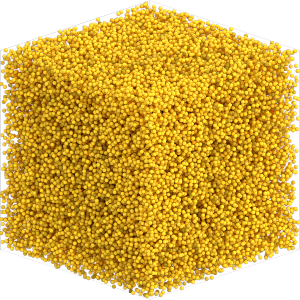

In [5]:
sim = sh.thermalize_and_randomize(sim, kT=.4, nsteps=100_000, log = True)

vh.render(sim.state.get_snapshot())

In [6]:
for i in range(10):
    sim = sh.make_simulation(frame)
    nsteps = 100_000 * (i + 1)
    sh.thermalize_and_randomize(sim, kT=.4, nsteps=nsteps, phase_name="randomization", log = True)
    print(f"Finished nsteps = {nsteps}")

print("done")

Using GPU device
Final device: <hoomd.device.GPU object at 0x7f72775aead0>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_100000_log.hdf5
Log period: 1000
Stopped HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_100000_log.hdf5
Wrote HDF5 metadata
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_100000_log.hdf5
Metadata group: metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_100000.gsd
Finished nsteps = 100000
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f72775ada90>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_200000_log.hdf5
Log period: 1000
Sto

In [15]:
paths = sim.logged_paths
log_data = lh.read_hdf5_log(paths["log_path"])

log_data.keys()

dict_keys(['hoomd-data', 'metadata'])

In [16]:
log_data["metadata"]["attrs"]

{'Lx': 50.0,
 'Ly': 50.0,
 'Lz': 50.0,
 'N': 48668,
 'actual_rho': 0.389344,
 'dt': 0.005,
 'epsilon_LJ': 1.0,
 'final_timestep': 100000,
 'kT': 0.4,
 'lj_mode': 'xplor',
 'log_period': 1000,
 'nsteps': 100000,
 'phase_name': 'randomization',
 'r_cut_LJ': 2.5,
 'r_on_LJ': 2.0,
 'seed': 1,
 'sigma_LJ': 1.0,
 'target_rho': 0.389344,
 'volume': 125000.0}

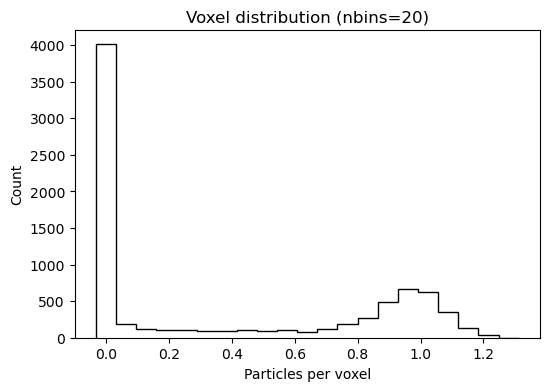

In [14]:
vh.plot_voxel_histogram(sim, nbins = 20);

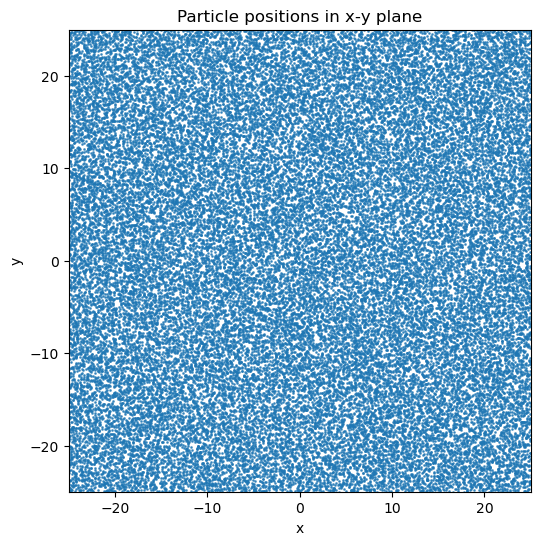

In [9]:
vh.plot_xy_particles(sim)

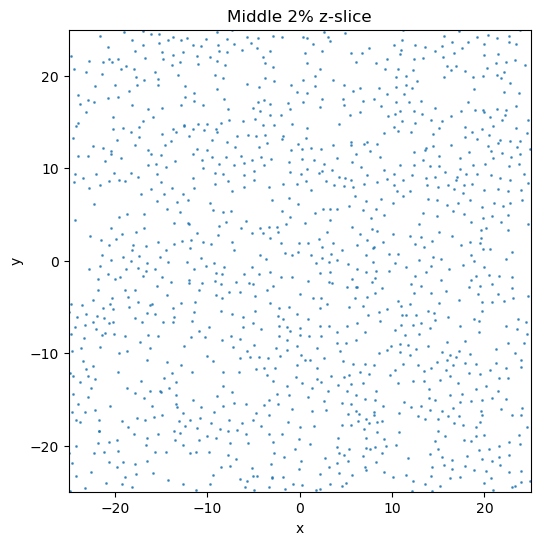

In [10]:
vh.plot_xy_slice(sim, fraction=0.025)

In [2]:
#how long does it take to phase separate
#    rho around crit rho = .4
#    kT sig smaller than crit temp


Voxel histogram for nsteps = 100,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_100000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f7277579310>


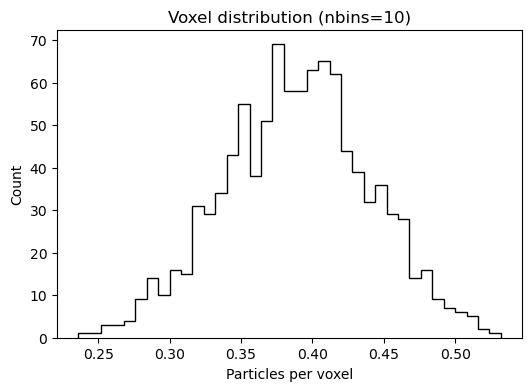


Voxel histogram for nsteps = 200,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_200000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725d366b30>


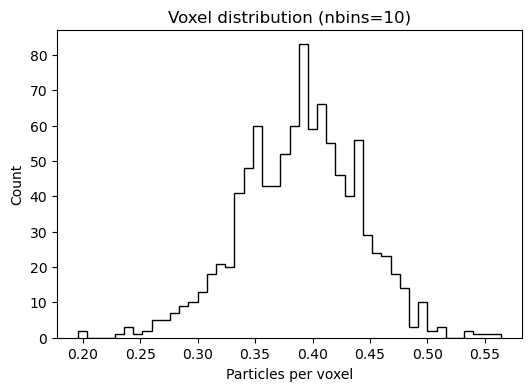


Voxel histogram for nsteps = 300,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_300000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725d294670>


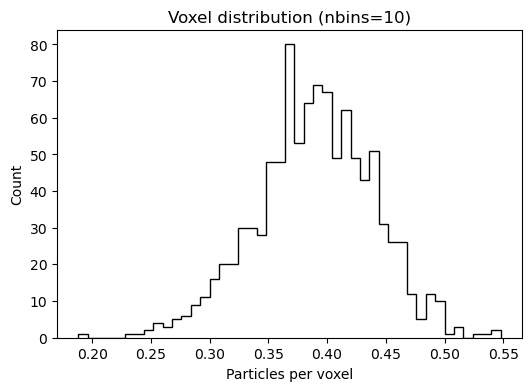


Voxel histogram for nsteps = 400,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_400000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f7756d50ef0>


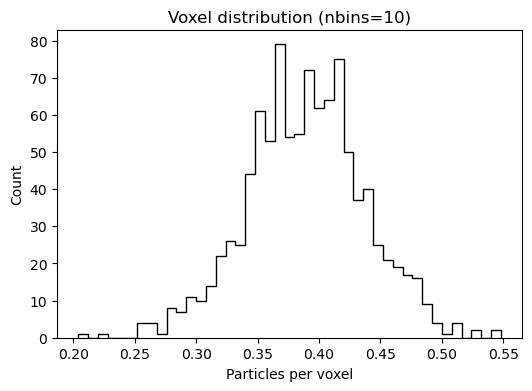


Voxel histogram for nsteps = 500,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_500000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725d271910>


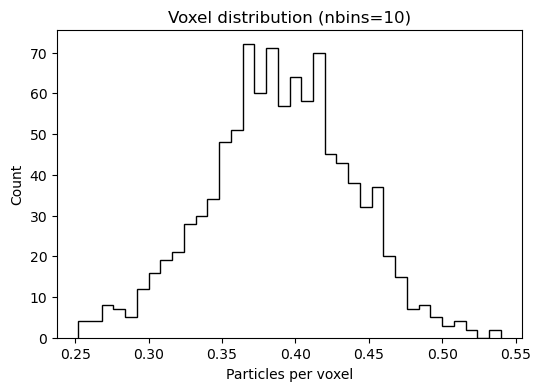


Voxel histogram for nsteps = 600,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_600000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725d0d7dd0>


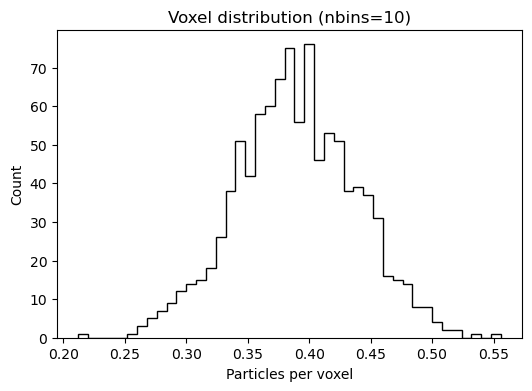


Voxel histogram for nsteps = 700,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_700000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725d39d860>


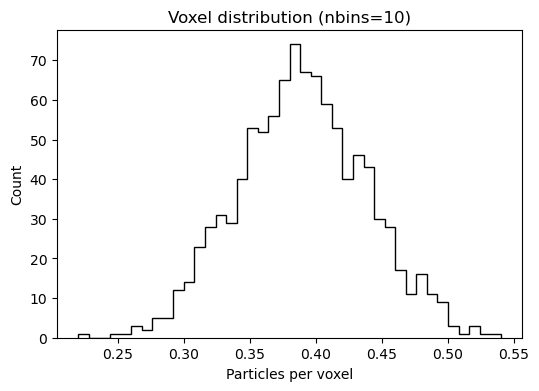


Voxel histogram for nsteps = 800,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_800000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725d39d910>


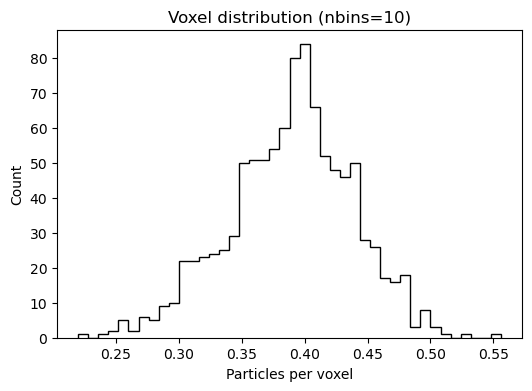


Voxel histogram for nsteps = 900,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_900000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725cfbd4f0>


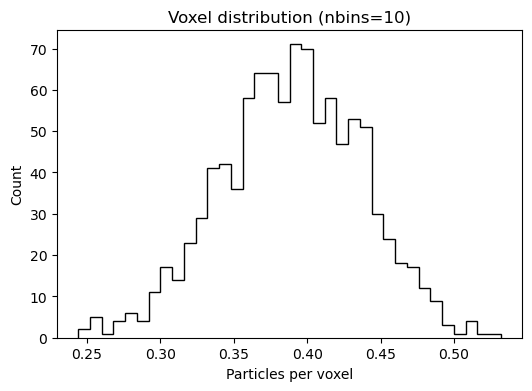


Voxel histogram for nsteps = 1,000,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000000.gsd
Starting Simulation -------------- Final device: <hoomd.device.GPU object at 0x7f725cfbfe30>


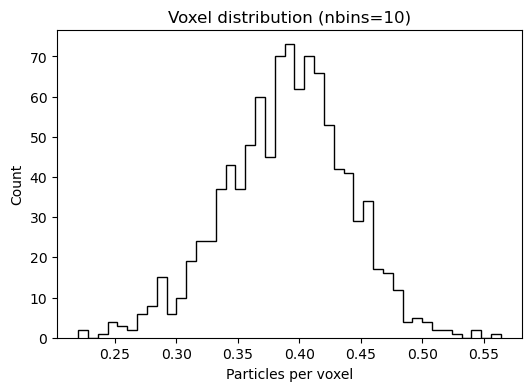

In [12]:
# ============================================================
# Plot voxel histograms for completed nsteps sweep
# ============================================================

from pathlib import Path
import gsd.hoomd


BoxLength = 50.0
rho = 0.39
kT = 0.40

folder = (
    THERMALIZED_STATES_ROOT
    / f"BoxLength_{BoxLength:.1f}"
    / f"rho_{rho:.2f}"
    / f"kT_{kT:.2f}"
)

nsteps_list = [
    100_000,
    200_000,
    300_000,
    400_000,
    500_000,
    600_000,
    700_000,
    800_000,
    900_000,
    1_000_000,
]

for nsteps in nsteps_list:
    state_path = folder / f"randomization_nsteps_{nsteps}.gsd"

    print("\n" + "=" * 80)
    print(f"Voxel histogram for nsteps = {nsteps:,}")
    print(state_path)
    print("=" * 80)

    with gsd.hoomd.open(name=str(state_path), mode="r") as f:
        frame = f[0]

    sim = sh.make_simulation(frame, kT=kT)
    sim.run(0)

    vh.plot_voxel_histogram(
        sim,
        nbins=10,
        use_density=False,
    )